In [49]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv
/kaggle/input/competitions/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv


# 1. Setup and load data

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [51]:
train_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv", index_col=0)
test_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv", index_col=0)
data_dict = pd.read_excel("/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls")

# 2. Data overview

In [52]:
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


In [53]:
train_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# 3. Data quality checking

In [54]:
train_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Từ bảng describe, ta có thể chú ý vài điều:
- Dataset mất cân bằng nhãn, do mean = 0.06 (6.7% khách hàng có label = 1)
- Biến "RevolvingUtilizationOfUnsecuredLines" có giá trị bất thường, do max = 50708. Bình thường biến nằm trong khoảng [0, 1]
- age có giá trị bất thường = 0
- "DebtRatio" có giá trị bất thường, do tỷ lệ chỉ nằm trong khoảng [0, 1]
- Số lần trễ hạn (NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse) có giá trị bất thường 98
- Missing values: biến MonthlyIncome và biến NumberOfDependents

In [55]:
train_data.duplicated().sum()

np.int64(609)

### Một vài vấn đề của bộ dữ liệu
* Dataset mất cân bằng nhãn
* Nhiều biến có giá trị bất thường: RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse
* Có 2 biến có missing values: MonthlyIncome, NumberOfDependents
* Dữ liệu tập train có những dòng trùng lặp

# 4. Univariate Analysis

### Phân tích nhãn

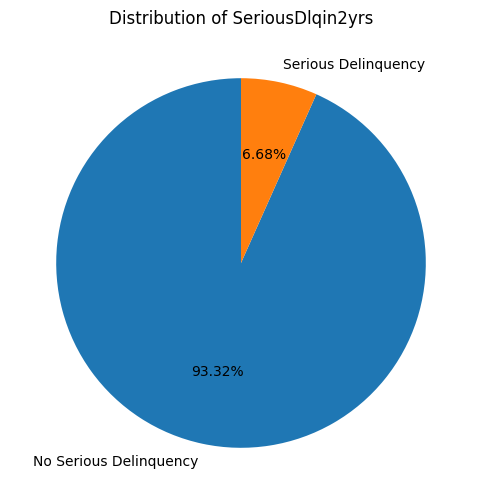

In [56]:
target_counts = train_data["SeriousDlqin2yrs"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    target_counts,
    labels=["No Serious Delinquency", "Serious Delinquency"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Distribution of SeriousDlqin2yrs")
plt.show()

Dataset bị mất cân bằng nghiêm trọng, chỉ có khoảng 6.68% khách hàng là có nhãn = 1

### Phân tích phân phối của từng biến

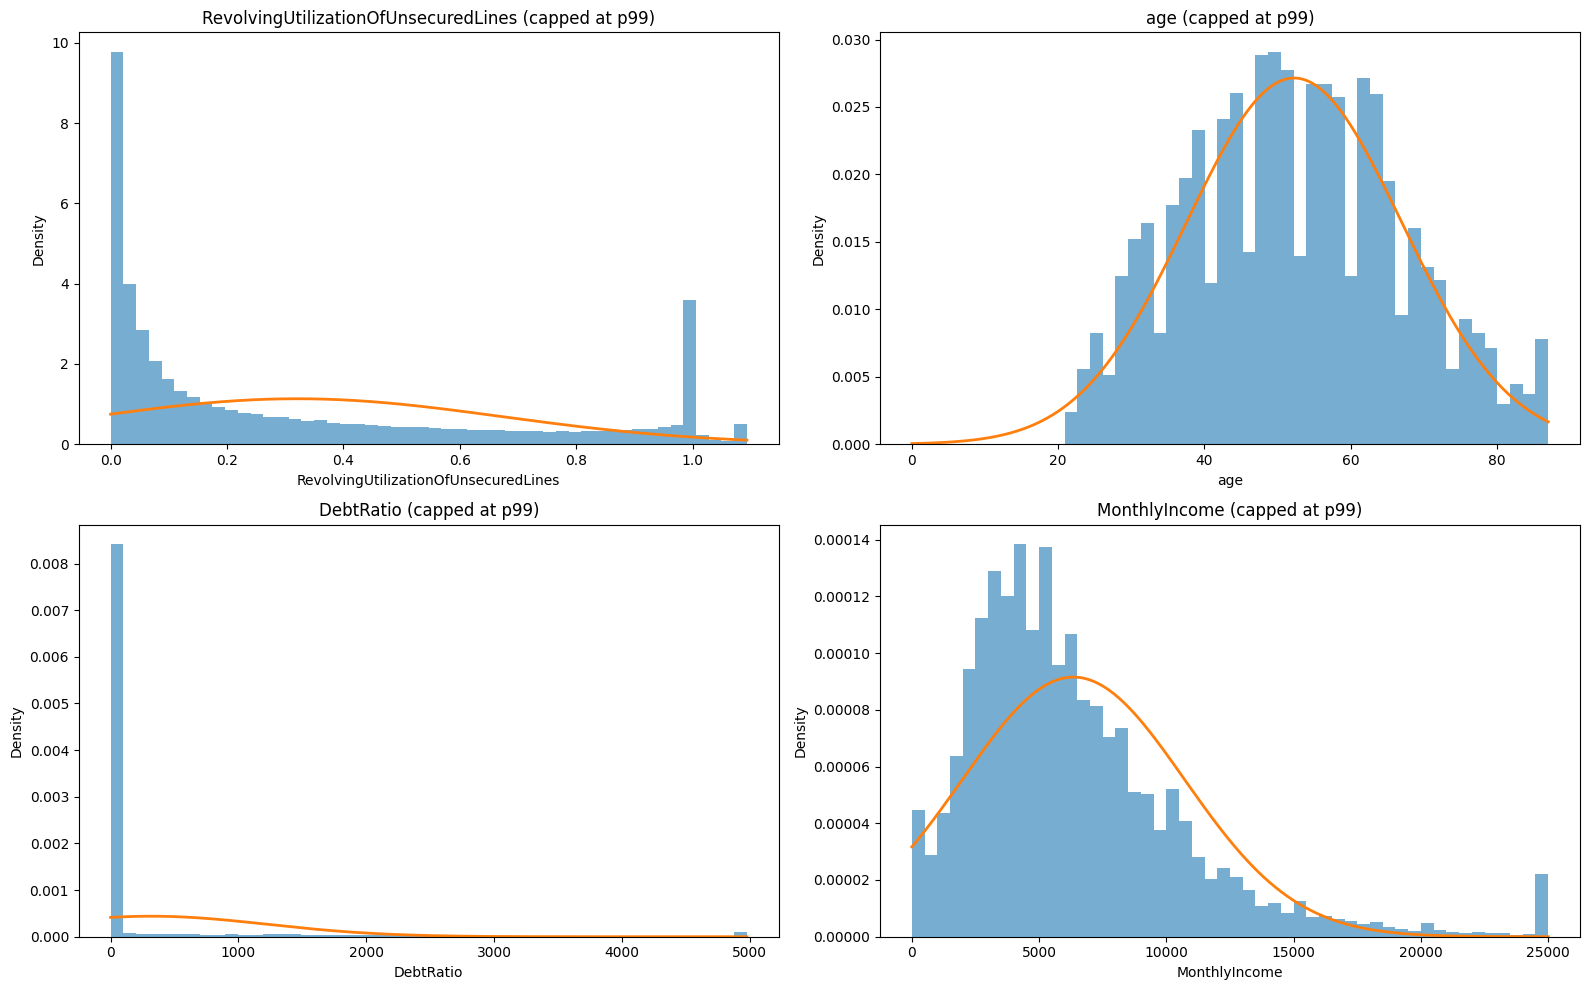

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(continuous_cols, 1):
    data = train_data[col].dropna()

    # Cap tại p99
    p99 = data.quantile(0.99)
    data_capped = data.clip(upper=p99)

    mu = data_capped.mean()
    sigma = data_capped.std()

    plt.subplot(2, 2, i)

    plt.hist(data_capped, bins=50, density=True, alpha=0.6)

    x = np.linspace(data_capped.min(), data_capped.max(), 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, linewidth=2)

    plt.title(f"{col} (capped at p99)")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

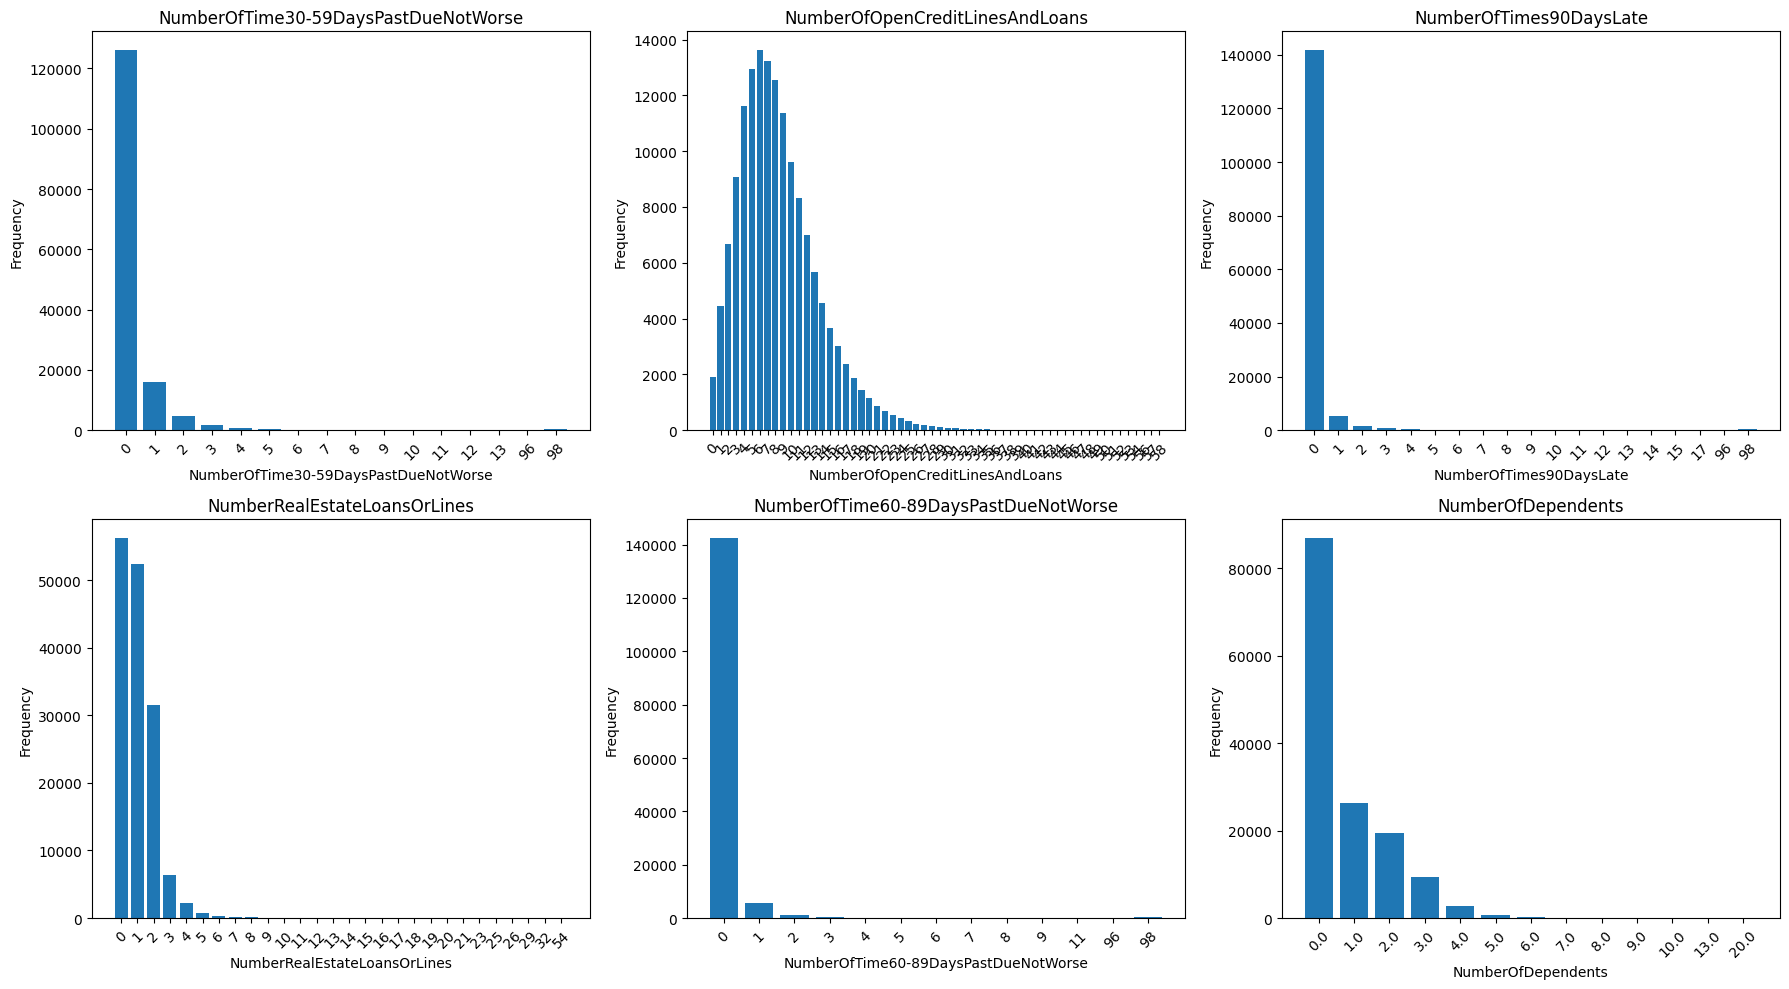

In [58]:
import matplotlib.pyplot as plt

discrete_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(discrete_cols, 1):
    data = train_data[col].dropna()

    value_counts = data.value_counts().sort_index()

    plt.subplot(2, 3, i)

    plt.bar(
        value_counts.index.astype(str),
        value_counts.values
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Từ các biểu đồ histogram, ta có thể nhìn thấy hầu hết các biến đều bị lệch phải, ngoại trừ biến age có phân phối gần chuẩn

### Kết luận từ phân tích đơn biến
- Nhãn dữ liệu bị mất cân bằng nghiêm trọng
- Hầu hết các biến đều lệch phải, trừ biến age

# 5. Outlier detection

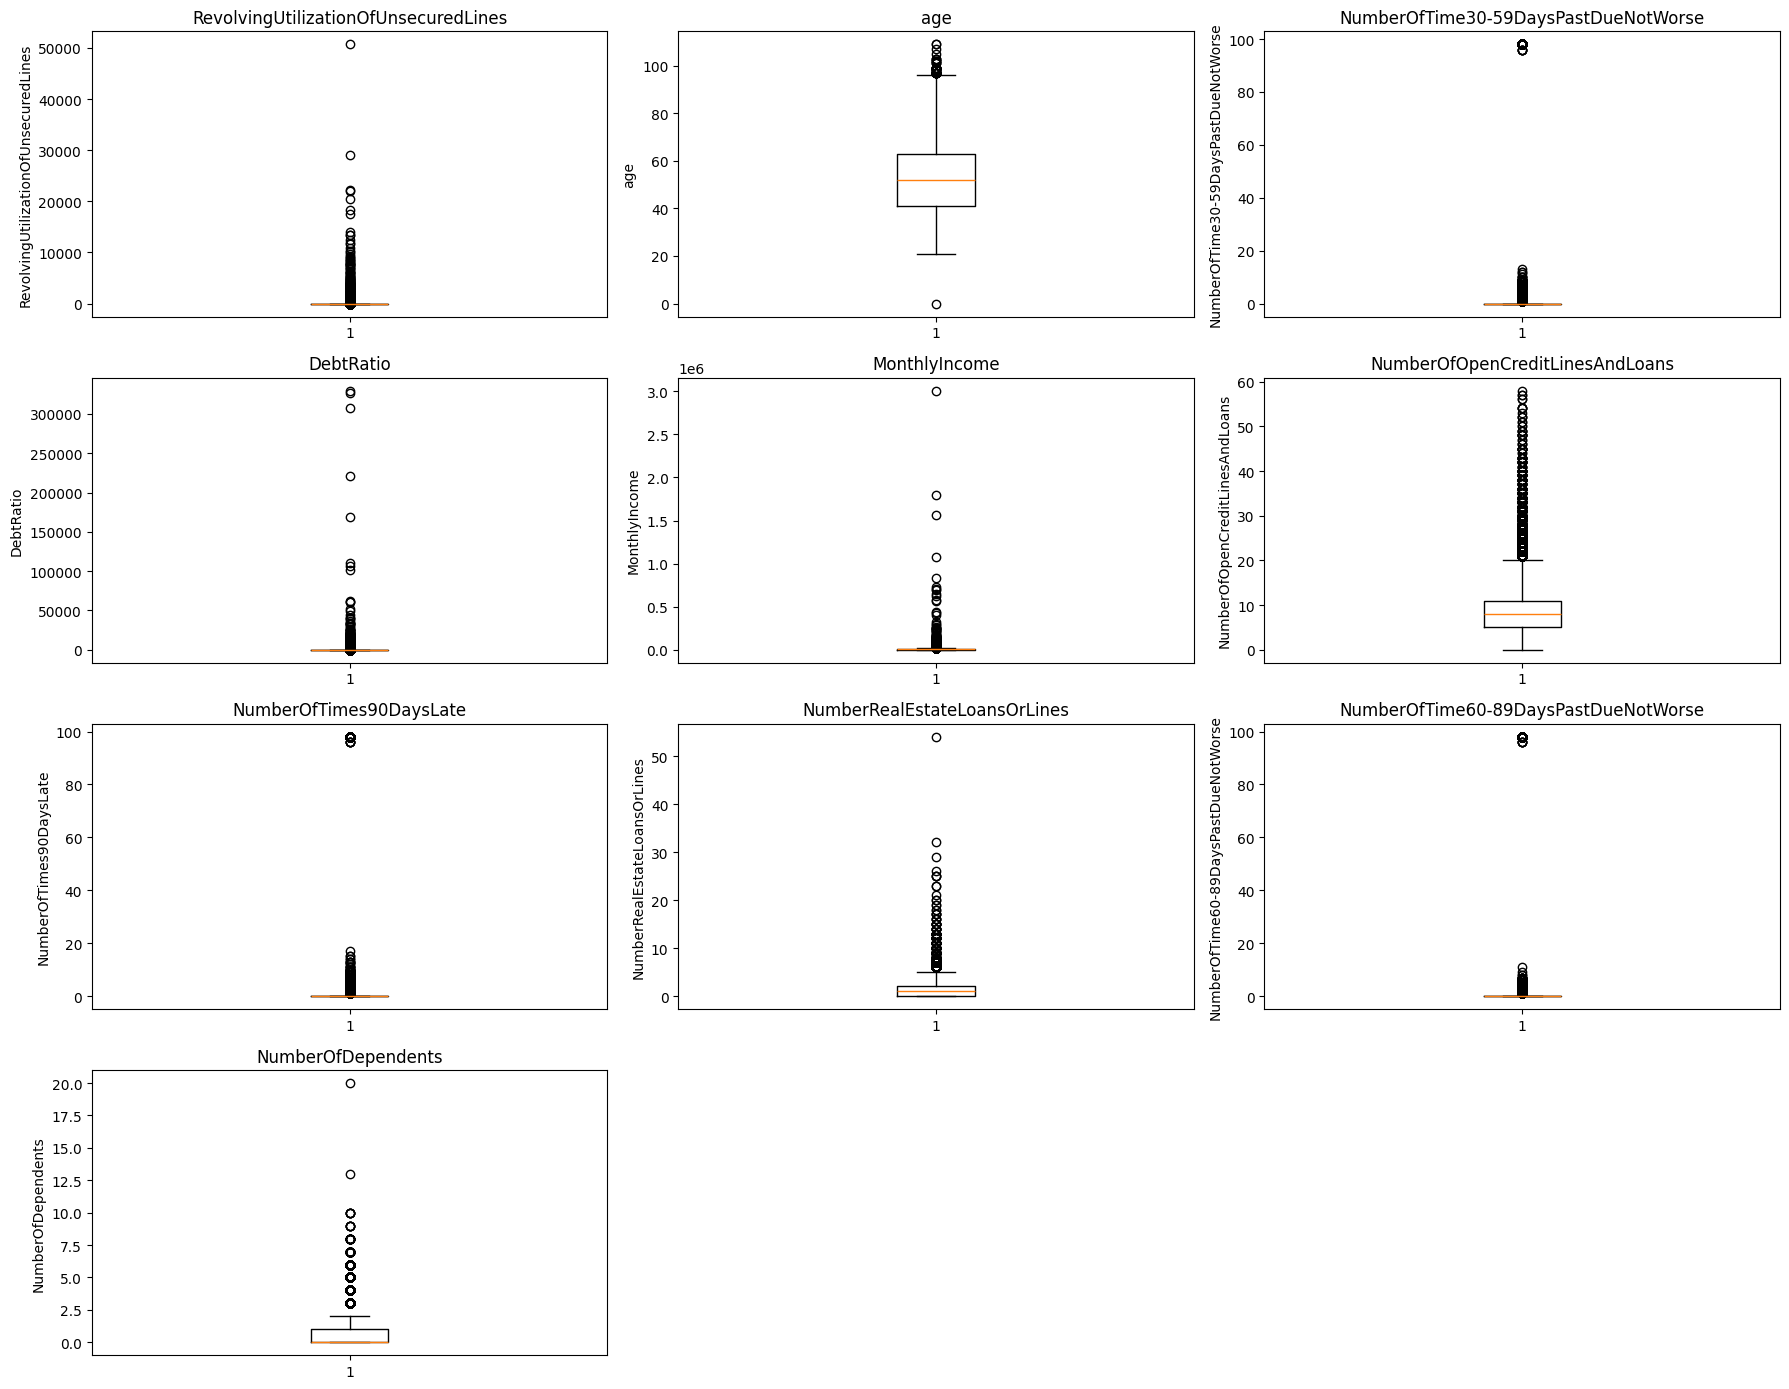

In [59]:
import matplotlib.pyplot as plt

num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(train_data[col].dropna(), vert=True)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Nhiều biến có outliers/giá trị bất thường: RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome, age

In [60]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]

mask_late = (train_data[late_cols] > 90).any(axis=1)
mask_age = (train_data["age"] == 0) | (train_data["age"] > 100)
mask_debt = train_data["DebtRatio"] > 1
mask_revolveline = train_data["RevolvingUtilizationOfUnsecuredLines"] > 1

print("Số dòng có ít nhất 1 cột trễ hạn > 90:", mask_late.sum())
print("Số dòng có age = 0 hoặc age > 100:", mask_age.sum())
print("Số dòng có DebtRatio > 1:", mask_debt.sum())
print("Số dòng có RevolvingUtilizationOfUnsecuredLines > 1:", mask_revolveline.sum())

print("\nSố lượng theo từng cột trễ hạn > 90:")
for col in late_cols:
    print(f"{col}: {(train_data[col] > 90).sum()}")

Số dòng có ít nhất 1 cột trễ hạn > 90: 269
Số dòng có age = 0 hoặc age > 100: 14
Số dòng có DebtRatio > 1: 35137
Số dòng có RevolvingUtilizationOfUnsecuredLines > 1: 3321

Số lượng theo từng cột trễ hạn > 90:
NumberOfTime30-59DaysPastDueNotWorse: 269
NumberOfTimes90DaysLate: 269
NumberOfTime60-89DaysPastDueNotWorse: 269


- Có vẻ có giá trị biến số lần nỡ hạn > 90 là giá trị missing, vì không thể miss hạn trả nợ > 90 lần được
- Biến tuổi = 0 là giá trị vô lý, do một người không thể được cấp khoản vay cho 1 người nhỏ tuổi

### Ta sẽ xem thử tại sao có 35000 dòng có DebtRatio > 1

In [61]:
train_data[(train_data["DebtRatio"] > 1)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
15,0,0.019657,76,0,477.000000,0.0,6,0,1,0,0.0
17,0,0.061086,78,0,2058.000000,NaN,10,0,2,0,0.0
26,1,0.392248,50,0,1.595253,4676.0,14,0,3,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
149977,0,0.000627,76,0,60.000000,NaN,5,0,0,0,0.0
149978,0,0.236450,29,0,349.000000,NaN,3,0,0,0,0.0
149985,0,0.037548,84,0,25.000000,NaN,5,0,0,0,0.0
149993,0,0.871976,50,0,4132.000000,NaN,11,0,1,0,3.0


In [62]:
train_data[(train_data["DebtRatio"] > 1) & (train_data["MonthlyIncome"].isnull())]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
7,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
17,0,0.061086,78,0,2058.0,NaN,10,0,2,0,0.0
33,0,0.083418,62,0,977.0,NaN,6,0,1,0,0.0
42,0,0.072898,81,0,75.0,NaN,7,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149977,0,0.000627,76,0,60.0,NaN,5,0,0,0,0.0
149978,0,0.236450,29,0,349.0,NaN,3,0,0,0,0.0
149985,0,0.037548,84,0,25.0,NaN,5,0,0,0,0.0
149993,0,0.871976,50,0,4132.0,NaN,11,0,1,0,3.0


In [63]:
train_data[(train_data["DebtRatio"] > 1) & (~train_data["MonthlyIncome"].isnull())]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
15,0,0.019657,76,0,477.000000,0.0,6,0,1,0,0.0
26,1,0.392248,50,0,1.595253,4676.0,14,0,3,0,1.0
45,0,0.368876,68,0,1687.500000,1.0,31,0,1,0,0.0
51,0,0.818978,73,0,3095.000000,0.0,9,0,1,1,0.0
64,0,0.009789,46,0,1.051398,3326.0,6,0,2,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
149842,1,0.009088,54,0,1.061506,11250.0,12,0,4,0,0.0
149883,0,0.062398,77,0,714.500000,1.0,3,0,0,0,0.0
149908,0,0.309121,60,0,1.124589,9125.0,11,0,4,0,0.0
149951,0,0.004827,61,0,1940.000000,0.0,10,0,1,0,0.0


In [64]:
train_data[(train_data["DebtRatio"] > 1) & (train_data["MonthlyIncome"] > 1)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
26,1,0.392248,50,0,1.595253,4676.0,14,0,3,0,1.0
64,0,0.009789,46,0,1.051398,3326.0,6,0,2,0,2.0
80,0,0.270523,41,0,2.797699,1042.0,11,0,2,0,2.0
83,0,0.017259,53,0,2.604511,12414.0,13,0,1,0,2.0
112,0,0.318446,58,0,1.382629,3833.0,26,0,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149809,0,1.000000,62,0,1.055178,2500.0,3,0,1,0,1.0
149824,0,0.820720,59,0,2.094595,2515.0,15,0,3,0,0.0
149842,1,0.009088,54,0,1.061506,11250.0,12,0,4,0,0.0
149908,0,0.309121,60,0,1.124589,9125.0,11,0,4,0,0.0


- Có tổng cộng 35137 hàng mà có DebtRatio > 1, trong đó 27904 hàng là do biến MonthlyIncome bị NaN nên DebtRatio có vẻ là tổng số nợ tuyệt đối
- 7233 hàng còn lại, có những giá trị > 1 hợp lệ, nhưng có những hàng MonthlyIncome = 0 hoặc = 1
- Những hàng mà có MonthlyIncome > 1, mà có DebtRatio > 1 có vẻ hợp lệ

-> Vì vậy có thể những giá trị NaN, 0, 1 của cột MonthlyIncome đều là những giá trị thiếu, làm cho biến DebtRatio có giá trị đột biến

### Ta sẽ xem thử tại sao có RevolvingUtilizationOfUnsecuredLines lớn bất thường

In [65]:
train_data[train_data["RevolvingUtilizationOfUnsecuredLines"] > 100]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
294,0,2340.0,45,0,0.339333,8333.0,7,0,2,0,2.0
698,1,2066.0,58,0,0.271121,6000.0,8,1,1,0,1.0
1992,1,1143.0,44,2,0.547762,6500.0,13,0,4,0,2.0
2332,0,6324.0,59,0,0.136673,11318.0,4,0,1,0,1.0
4279,0,1982.0,33,0,0.144982,8000.0,4,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
145588,0,7452.0,52,0,0.351365,10000.0,5,0,2,0,3.0
149103,0,6109.0,43,0,0.229902,12500.0,9,0,2,0,0.0
149161,0,22000.0,38,0,1.080020,3973.0,7,0,2,0,3.0
149246,0,771.0,52,0,0.832021,8000.0,13,0,3,0,0.0


### Kết luận cho phần phát hiện outliers
- Các biến trễ hạn có 269 dòng có giá trị > 90 ở cả 3 cột, nhiều khả năng là mã bất thường/missing code, không phải số lần trễ hạn thật.
- Biến age có 14 dòng bất thường với age = 0 hoặc age > 100; đặc biệt age = 0 là giá trị không hợp lệ và cần xử lý.
- DebtRatio > 1 xuất hiện nhiều (35,137 dòng), trong đó phần lớn đi kèm MonthlyIncome = NaN, 0 hoặc 1, cho thấy nhiều giá trị DebtRatio cao có thể liên quan đến thu nhập bị thiếu.
- RevolvingUtilizationOfUnsecuredLines > 1 có 3,321 dòng; với nhiều dòng cho giá trị lớn bất thường

# 6. Multivariate Analysis

### Biểu đồ giữa feature và target

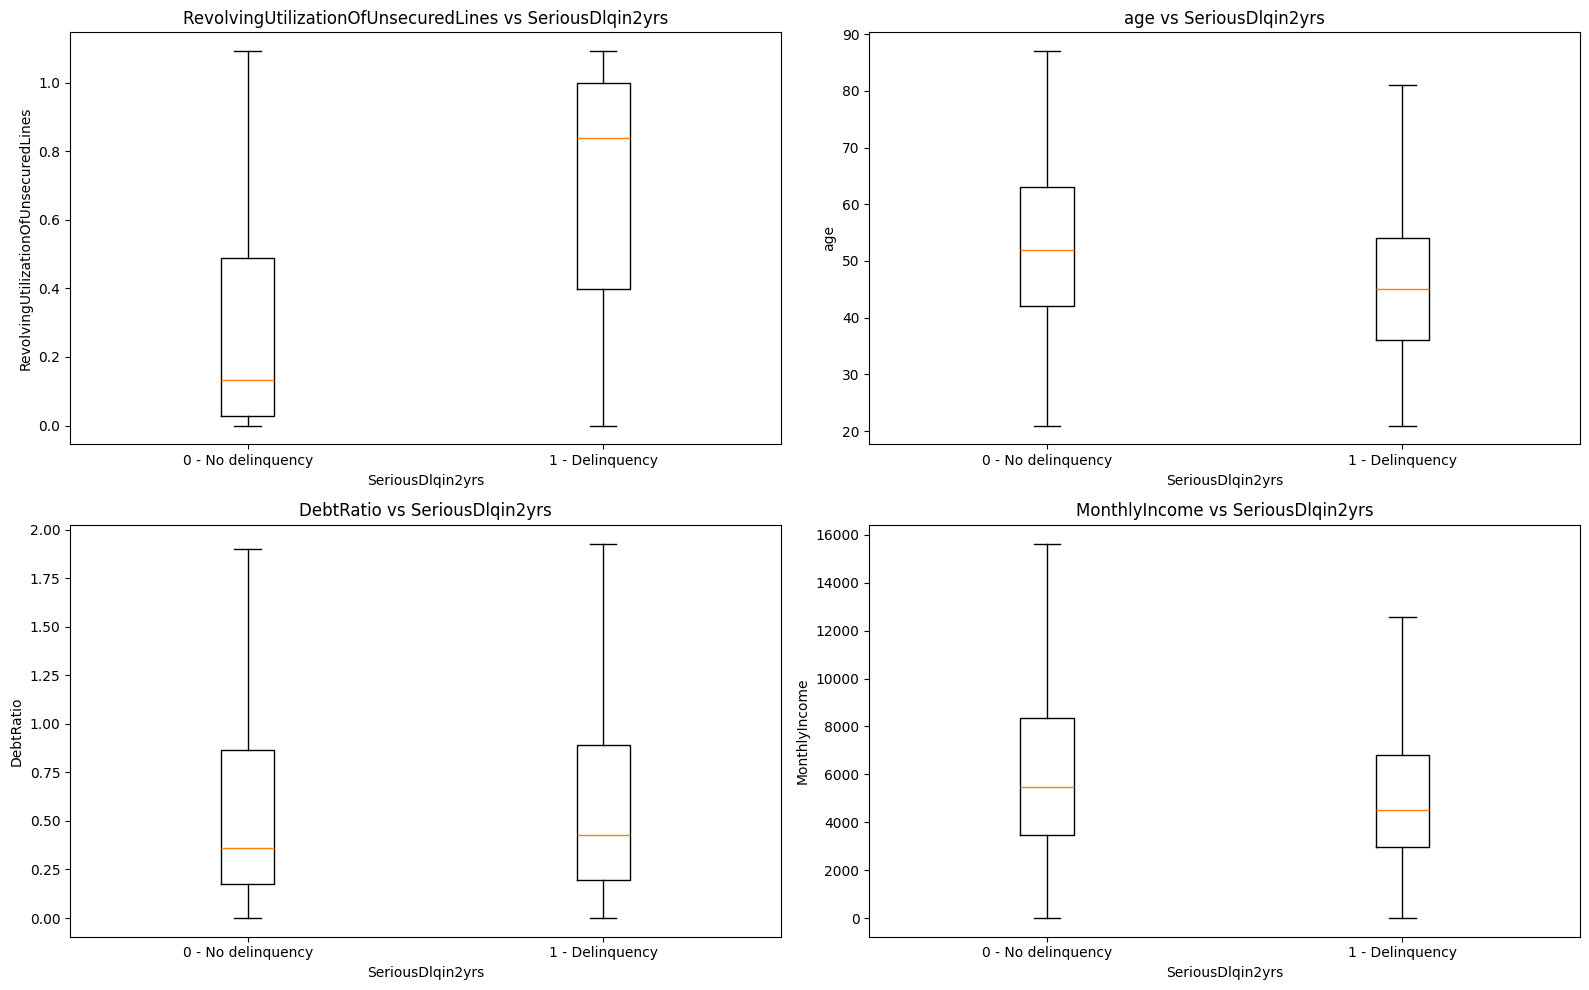

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target = "SeriousDlqin2yrs"

continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(continuous_cols, 1):
    data = train_data[[col, target]].dropna().copy()
    
    p99 = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=p99)

    group_0 = data.loc[data[target] == 0, col]
    group_1 = data.loc[data[target] == 1, col]

    plt.subplot(2, 2, i)
    plt.boxplot(
        [group_0, group_1],
        tick_labels=["0 - No delinquency", "1 - Delinquency"],
        showfliers=False
    )

    plt.title(f"{col} vs {target}")
    plt.xlabel(target)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

- RevolvingUtilizationOfUnsecuredLines, và age là 2 biến phân biệt target rõ nhất
- Không có sự khác biệt đáng kể giữa 2 nhóm đối với biến DebtRatio và Monthly Income

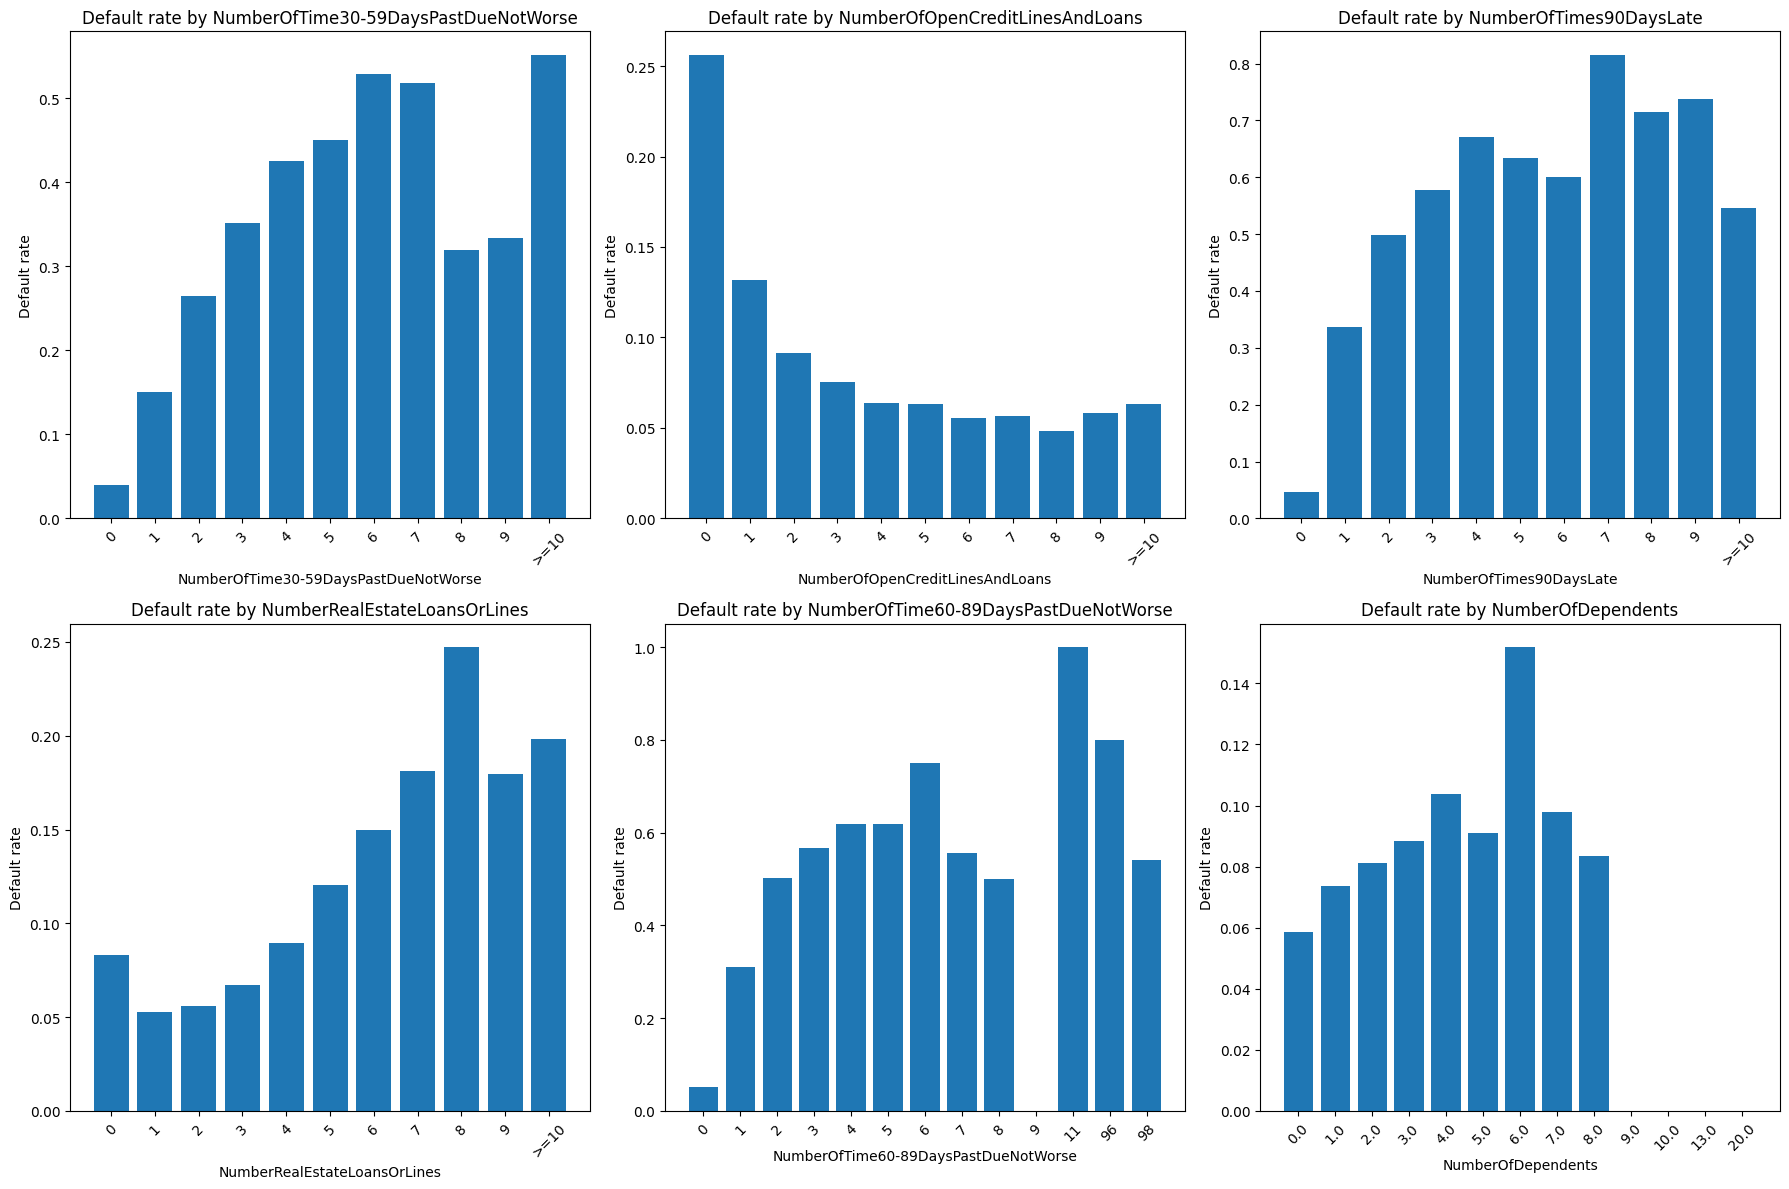

In [67]:
discrete_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(discrete_cols, 1):
    data = train_data[[col, target]].dropna().copy()

    if data[col].nunique() > 15:
        data[col + "_bin"] = data[col].apply(lambda x: ">=10" if x >= 10 else str(int(x)))
        plot_col = col + "_bin"

        order = [str(i) for i in range(10)] + [">=10"]
    else:
        data[plot_col := col] = data[col].astype(str)
        order = sorted(data[plot_col].unique(), key=lambda x: float(x))

    default_rate = (
        data.groupby(plot_col)[target]
        .mean()
        .reindex(order)
        .dropna()
    )

    plt.subplot(2, 3, i)
    plt.bar(default_rate.index.astype(str), default_rate.values)

    plt.title(f"Default rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Số lần trễ hạn trước đấy càng cao thì default rate càng tăng rõ rệt.
- `NumberOfOpenCreditLinesAndLoans` và `NumberRealEstateLoansOrLines` thể hiện quan hệ phi tuyến với default rate, do đó nên dùng binning thay vì giả định quan hệ tuyến tính.
- `NumberOfDependents` có xu hướng default rate tăng khi số người phụ thuộc tăng

### Ma trận tương quan giữa các biến feature

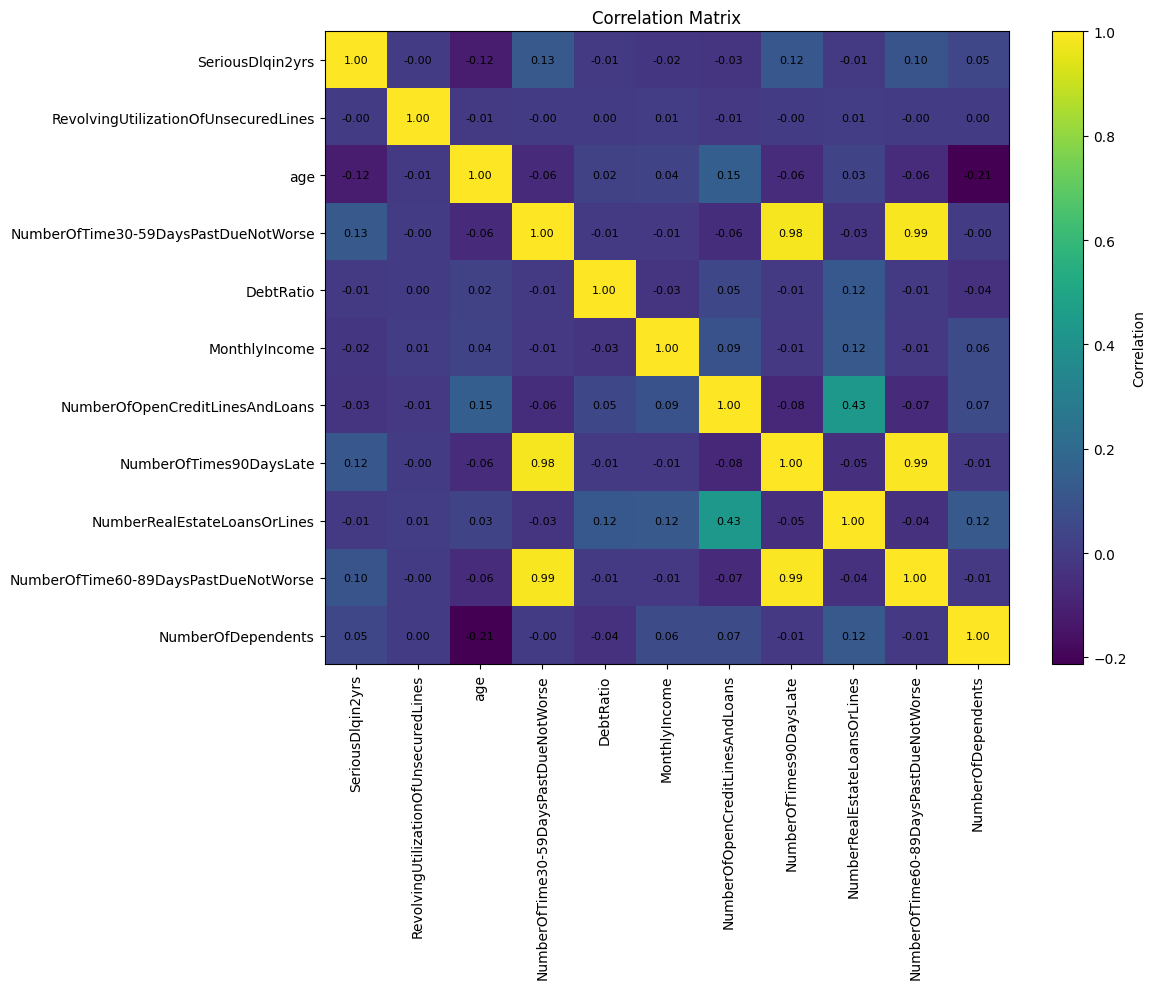

In [69]:
import matplotlib.pyplot as plt

corr_cols = [
    "SeriousDlqin2yrs",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

corr_matrix = train_data[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Correlation Matrix")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Ta có thể thấy rõ các biến trễ hạn có tương quan mạnh, có thể gây hiện tượng đa cộng tuyến nếu dùng Logistic Regression

# 7. Conclusion 

### Kết luận từ việc phân tích EDA dữ liệu
- Bộ dữ liệu bị mất cân bằng nhãn nghiêm trọng, tỷ lệ khách hàng default chỉ khoảng 6.7%.
- Dữ liệu có nhiều giá trị bất thường và missing values, đặc biệt ở MonthlyIncome, NumberOfDependents, các biến trễ hạn, age, DebtRatio, và RevolvingUtilizationOfUnsecuredLines.
- Về khả năng phân biệt target, RevolvingUtilizationOfUnsecuredLines và age là hai biến nổi bật nhất. Các biến liên quan đến lịch sử trễ hạn có ảnh hưởng mạnh đến default rate, cụ thể số lần trễ hạn càng cao thì rủi ro càng tăng. NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines cũng có ảnh hưởng đến khả năng default, nhưng có vẻ như theo quan hệ phi tuyến
- Ma trận tương quan cho thấy các biến trễ hạn có tương quan cao, có thể dẫn đến đa cộng tuyến nếu dùng Logistic Regression.